## DebtRank Stress Testing under Overlapping Portfolio Exposure

- Author: Abbinav Sankar Kailasam
- Project: Systemic Risk in Interbank Networks: DebtRank Stress Testing under Counterparty Default and Overlapping Portfolio Contagion

In [12]:
# Import the necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

import networkx as nx

In [13]:
equity = pd.read_csv("data/bankEquities.csv", header=None).values.flatten().astype(float)
L = pd.read_csv("data/interbankExposures.csv", header=None).values.astype(float)
S = pd.read_csv("data/bankAssetWeightedNetwork.csv", header=None).values.astype(float)

N = len(equity)
A = S.shape[1]

print(f"  Banks                    : {N}")
print(f"  External assets          : {A}")
print(f"  Non-zero portfolio links : {(S > 0).sum()}")
print(f"  Asset holdings range     : {S[S>0].min():.1f}  –  {S.max():.1f}")

  Banks                    : 145
  External assets          : 20
  Non-zero portfolio links : 586
  Asset holdings range     : 4912.2  –  423900000.0


In [14]:
def build_omega(S, equity, lam):
    N, A = S.shape
    Omega = np.zeros((N, N))

    for a in range(A):
        denom = np.sum(S[:, a] ** 2)
        if denom > 0:
            Omega += np.outer(S[:, a], S[:, a]) / denom

    Omega *= lam

    np.fill_diagonal(Omega, 0.0)
    W_omega = np.minimum(Omega, 1.0)
    return Omega, W_omega

def run_debtrank(W_eff, equity, initial_shock_idx, shock_magnitude=1.0):
    N      = len(equity)
    h      = np.zeros(N)
    status = np.zeros(N, dtype=int)

    for idx in initial_shock_idx:
        h[idx]      = shock_magnitude
        status[idx] = 1

    h_history     = [h.copy()]
    total_equity  = equity.sum()

    for t in range(1000):
        h_new     = h.copy()
        converged = True

        for i in range(N):
            if status[i] != 0:
                continue
            contribution = 0.0
            for j in range(N):
                if status[j] == 1:
                    contribution += W_eff[j, i] * h[j]
            new_h_i = min(h[i] + contribution, 1.0)
            if new_h_i > h_new[i] + 1e-12:
                h_new[i]  = new_h_i
                converged = False

        for i in range(N):
            if status[i] == 1:
                status[i] = 2

        for i in range(N):
            if status[i] == 0 and h_new[i] > 1e-12:
                status[i] = 1

        h = h_new
        h_history.append(h.copy())

        if converged:
            break

    h0 = np.zeros(N)
    for idx in initial_shock_idx:
        h0[idx] = shock_magnitude

    SL = np.sum(equity * (h - h0)) / total_equity
    return h, max(SL, 0.0), t + 1, np.array(h_history)

In [15]:
lam_baseline = 1.0
R_baseline   = 0.4

Omega_base, W_omega_base = build_omega(S, equity, lam_baseline)

print("=" * 60)
print(f"STEP 2: Ω Matrix  (λ = {lam_baseline})")
print("=" * 60)
print(f"Ω non-zero entries       : {(Omega_base > 0).sum()}")
print(f"Ω max value              : {Omega_base.max():.2f}")
print(f"W_omega max (post-cap)   : {W_omega_base.max():.4f}")
print(f"W_omega mean (non-zero)  : {W_omega_base[W_omega_base>0].mean():.6f}")

STEP 2: Ω Matrix  (λ = 1.0)
Ω non-zero entries       : 11720
Ω max value              : 0.77
W_omega max (post-cap)   : 0.7666
W_omega mean (non-zero)  : 0.008108


In [16]:
total_outgoing = L.sum(axis=1)
largest_bank   = int(np.argmax(total_outgoing))
top5_banks     = list(np.argsort(total_outgoing)[-5:][::-1])

rng          = np.random.default_rng(seed=42)
random_bank  = int(rng.integers(0, N))

print(f"Largest bank  : Bank {largest_bank}")
print(f"Top-5 banks   : {top5_banks}")
print(f"Random bank (seed=42) : Bank {random_bank}")

Largest bank  : Bank 128
Top-5 banks   : [np.int64(128), np.int64(3), np.int64(7), np.int64(82), np.int64(83)]
Random bank (seed=42) : Bank 12


In [17]:
W_eff_omega = W_omega_base * (1 - R_baseline)

h_A2, SL_A2, rounds_A2, hist_A2 = run_debtrank(W_eff_omega, equity, [largest_bank])
h_B2, SL_B2, rounds_B2, hist_B2 = run_debtrank(W_eff_omega, equity, top5_banks)
h_C2, SL_C2, rounds_C2, hist_C2 = run_debtrank(W_eff_omega, equity, [random_bank])

print(f"Scenario A (largest bank)             → SL = {SL_A2*100:.2f}%  ({rounds_A2} rounds)")
print(f"Scenario B (top-5)                    → SL = {SL_B2*100:.2f}%  ({rounds_B2} rounds)")
print(f"Scenario C (random bank {random_bank:3d}, seed=42) → SL = {SL_C2*100:.2f}%  ({rounds_C2} rounds)")

W_L      = np.minimum(L / equity[:, None], 1.0)
W_eff_L  = W_L * (1 - R_baseline)

_, SL_A1, _, hist_A1 = run_debtrank(W_eff_L, equity, [largest_bank])
_, SL_B1, _, hist_B1 = run_debtrank(W_eff_L, equity, top5_banks)
_, SL_C1, _, hist_C1 = run_debtrank(W_eff_L, equity, [random_bank])

Scenario A (largest bank)             → SL = 8.61%  (3 rounds)
Scenario B (top-5)                    → SL = 20.48%  (3 rounds)
Scenario C (random bank  12, seed=42) → SL = 0.12%  (3 rounds)


In [18]:
lam_values = np.linspace(0, 2, 100)
SL_A_lam, SL_B_lam, SL_C_lam = [], [], []

for lam in lam_values:
    _, W_o = build_omega(S, equity, lam)
    W_e    = W_o * (1 - R_baseline)
    _, sl_a, _, _ = run_debtrank(W_e, equity, [largest_bank])
    _, sl_b, _, _ = run_debtrank(W_e, equity, top5_banks)
    _, sl_c, _, _ = run_debtrank(W_e, equity, [random_bank])
    SL_A_lam.append(sl_a)
    SL_B_lam.append(sl_b)
    SL_C_lam.append(sl_c)

print(f"λ sweep complete: {len(lam_values)} values")

λ sweep complete: 100 values


In [19]:
print("  R sweep ...")

R_values = np.linspace(0, 1, 100)
SL_A_R2, SL_B_R2, SL_C_R2 = [], [], []

for R in R_values:
    W_e = W_omega_base * (1 - R)
    _, sl_a, _, _ = run_debtrank(W_e, equity, [largest_bank])
    _, sl_b, _, _ = run_debtrank(W_e, equity, top5_banks)
    _, sl_c, _, _ = run_debtrank(W_e, equity, [random_bank])
    SL_A_R2.append(sl_a)
    SL_B_R2.append(sl_b)
    SL_C_R2.append(sl_c)

print(f"R sweep complete: {len(R_values)} values")

  R sweep ...
R sweep complete: 100 values


In [20]:
DR2_scores = []
for i in range(N):
    _, sl, _, _ = run_debtrank(W_eff_omega, equity, [i])
    DR2_scores.append(sl)
DR2_scores = np.array(DR2_scores)

# Also recompute Part 1 scores
DR1_scores = []
for i in range(N):
    _, sl, _, _ = run_debtrank(W_eff_L, equity, [i])
    DR1_scores.append(sl)
DR1_scores = np.array(DR1_scores)

top10_DR2 = np.argsort(DR2_scores)[-10:][::-1]
top10_DR1 = np.argsort(DR1_scores)[-10:][::-1]

print("  Top-10 banks by Overlapping Portfolio DebtRank:")
for rank, idx in enumerate(top10_DR2, 1):
    print(f"    {rank:2d}. Bank {idx:3d}  →  DR2 = {DR2_scores[idx]*100:.3f}%   "
          f"(DR1 = {DR1_scores[idx]*100:.3f}%)")

  Top-10 banks by Overlapping Portfolio DebtRank:
     1. Bank  27  →  DR2 = 13.881%   (DR1 = 4.540%)
     2. Bank 136  →  DR2 = 13.488%   (DR1 = 0.721%)
     3. Bank  72  →  DR2 = 12.000%   (DR1 = 11.138%)
     4. Bank   7  →  DR2 = 9.821%   (DR1 = 19.423%)
     5. Bank 141  →  DR2 = 9.470%   (DR1 = 15.139%)
     6. Bank   3  →  DR2 = 9.106%   (DR1 = 19.338%)
     7. Bank 128  →  DR2 = 8.608%   (DR1 = 15.853%)
     8. Bank  82  →  DR2 = 8.158%   (DR1 = 2.052%)
     9. Bank 140  →  DR2 = 8.078%   (DR1 = 10.622%)
    10. Bank 120  →  DR2 = 8.031%   (DR1 = 19.696%)


In [21]:
lam_grid = np.linspace(0, 2,  26)
R_grid   = np.linspace(0, 1,  26)
SL_grid  = np.zeros((len(R_grid), len(lam_grid)))

for li, lam in enumerate(lam_grid):
    _, W_o = build_omega(S, equity, lam)
    for ri, R in enumerate(R_grid):
        W_e = W_o * (1 - R)
        _, sl, _, _ = run_debtrank(W_e, equity, [largest_bank])
        SL_grid[ri, li] = sl * 100

print(f"Grid computed: {len(lam_grid)} × {len(R_grid)} = {SL_grid.size} points")

Grid computed: 26 × 26 = 676 points


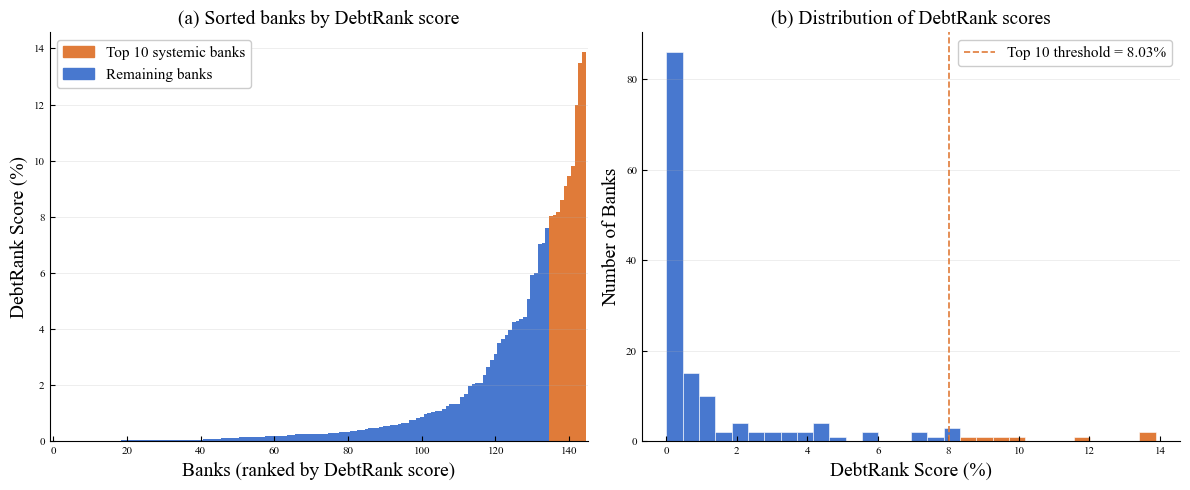

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sorted_idx    = np.argsort(DR2_scores)
sorted_scores = DR2_scores[sorted_idx] * 100

bar_cols = ["#e07b39" if i in top10_DR2 else "#4878cf" for i in sorted_idx]
ax.bar(np.arange(N), sorted_scores, color=bar_cols, width=1.0, linewidth=0)
ax.set_xlabel("Banks (ranked by DebtRank score)", fontsize=14)
ax.set_ylabel("DebtRank Score (%)", fontsize=14)
ax.set_title("(a) Sorted banks by DebtRank score", fontsize=14)
ax.set_xlim(-1, N)
ax.grid(True, axis="y", alpha=0.3, linewidth=0.5)
ax.tick_params(direction="in", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
p1 = mpatches.Patch(color="#e07b39", label="Top 10 systemic banks")
p2 = mpatches.Patch(color="#4878cf", label="Remaining banks")
ax.legend(handles=[p1, p2], fontsize=11, framealpha=1.0, edgecolor="#cccccc")

ax2 = axes[1]
threshold_dr = DR2_scores[top10_DR2[-1]] * 100
counts, bins, patches = ax2.hist(DR2_scores * 100, bins=30, edgecolor="white", linewidth=0.4)
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor("#e07b39" if left >= threshold_dr else "#4878cf")

ax2.axvline(threshold_dr, color="#e07b39", lw=1.2, ls="--", label=f"Top 10 threshold = {threshold_dr:.2f}%")
ax2.set_xlabel("DebtRank Score (%)", fontsize=14)
ax2.set_ylabel("Number of Banks", fontsize=14)
ax2.set_title("(b) Distribution of DebtRank scores", fontsize=14)
ax2.grid(True, axis="y", alpha=0.3, linewidth=0.5)
ax2.tick_params(direction="in", labelsize=8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(fontsize=11, framealpha=1.0, edgecolor="#cccccc")

plt.tight_layout()
plt.show()

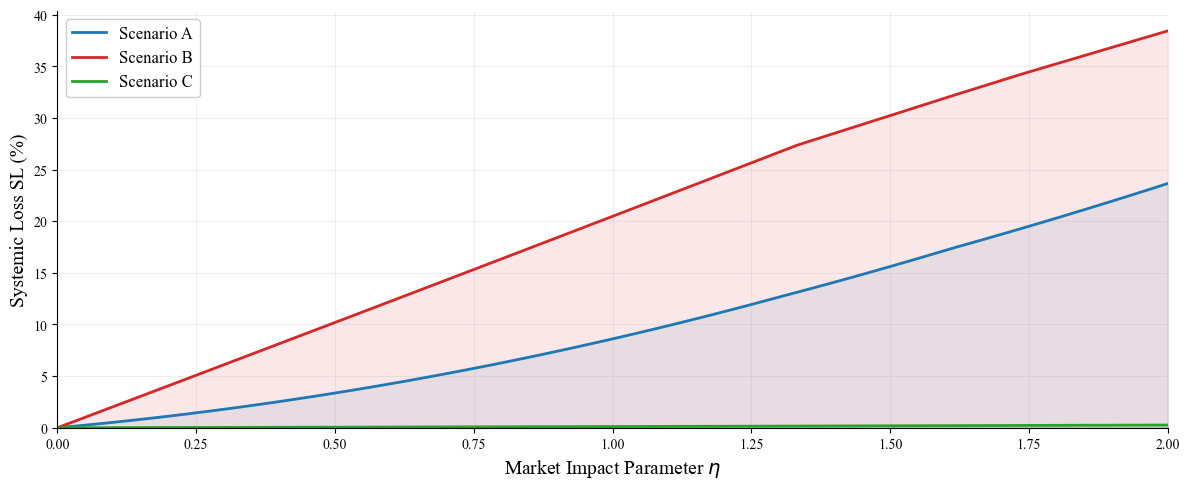

In [23]:
C_A   = "#1f77b4"   # blue   — Scenario A (largest bank)
C_B   = "#d62728"   # red    — Scenario B (top-5)
C_C   = "#2ca02c"   # green  — Scenario C (random bank)
C_BL  = "black"     # baseline marker

fig, ax = plt.subplots(figsize=(12, 5))
 
lam_arr = np.asarray(lam_values)
sl_A    = np.asarray(SL_A_lam) * 100
sl_B    = np.asarray(SL_B_lam) * 100
sl_C    = np.asarray(SL_C_lam) * 100
    
ax.fill_between(lam_arr, sl_A, alpha=0.10, color=C_A)
ax.fill_between(lam_arr, sl_B, alpha=0.10, color=C_B)
ax.fill_between(lam_arr, sl_C, alpha=0.10, color=C_C)

ax.plot(lam_arr, sl_A, color=C_A, lw=2.0, label=f"Scenario A")
ax.plot(lam_arr, sl_B, color=C_B, lw=2.0, label="Scenario B")
ax.plot(lam_arr, sl_C, color=C_C, lw=2.0, label=f"Scenario C")
 
ax.set_xlabel("Market Impact Parameter $\\eta$", fontsize=14)
ax.set_ylabel("Systemic Loss SL (%)", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 2)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(fontsize=12, framealpha=1.0, edgecolor="#cccccc")
 
plt.tight_layout()
plt.show()

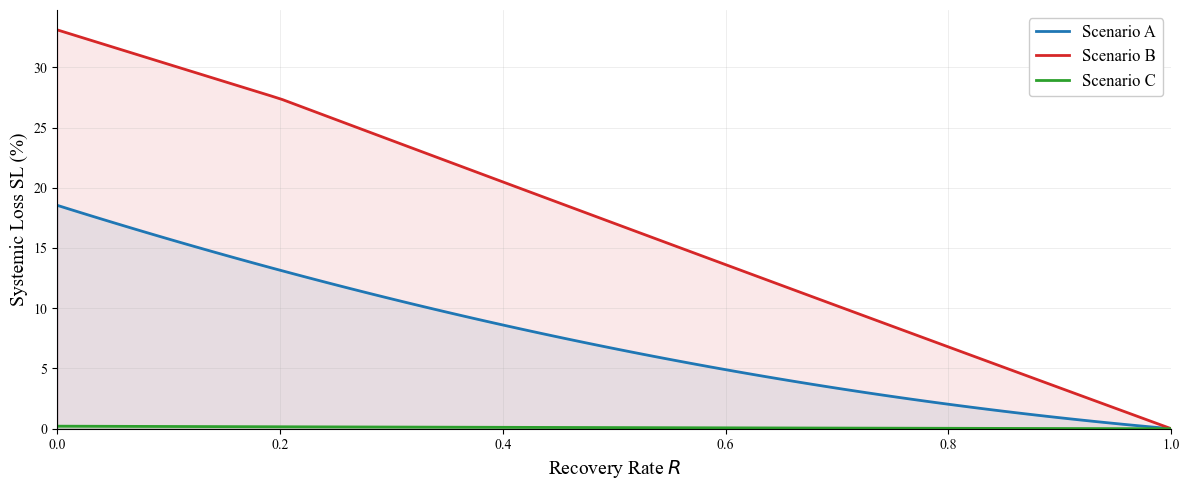

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

R_arr = np.asarray(R_values)
sl_A2 = np.asarray(SL_A_R2) * 100
sl_B2 = np.asarray(SL_B_R2) * 100
sl_C2 = np.asarray(SL_C_R2) * 100
 
ax.fill_between(R_arr, sl_A2, alpha=0.10, color=C_A)
ax.fill_between(R_arr, sl_B2, alpha=0.10, color=C_B)
ax.fill_between(R_arr, sl_C2, alpha=0.10, color=C_C)
 
ax.plot(R_arr, sl_A2, color=C_A, lw=2.0, label=f"Scenario A")
ax.plot(R_arr, sl_B2, color=C_B, lw=2.0, label="Scenario B")
ax.plot(R_arr, sl_C2, color=C_C, lw=2.0, label=f"Scenario C")
 
ax.set_xlabel("Recovery Rate $R$", fontsize=14)
ax.set_ylabel("Systemic Loss SL (%)", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(fontsize=12, framealpha=1.0, edgecolor="#cccccc")
 
plt.tight_layout()
plt.show()

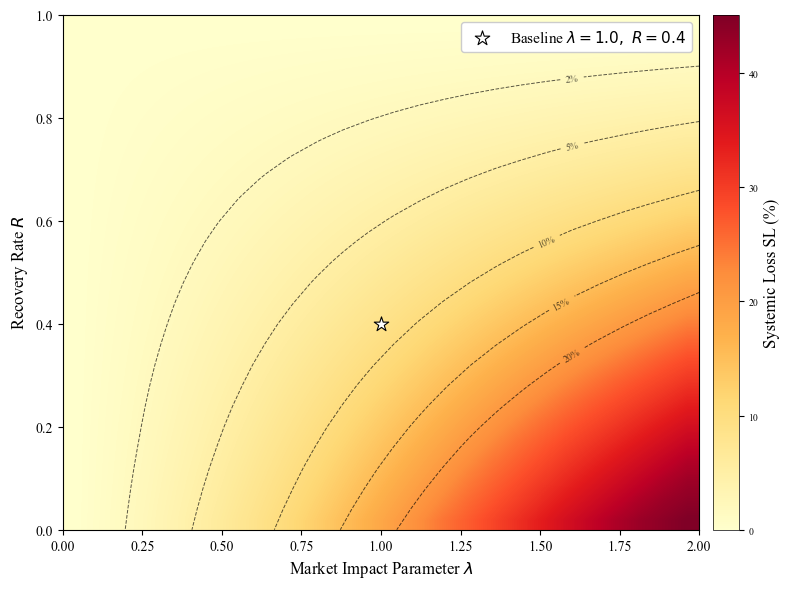

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(SL_grid, origin="lower", aspect="auto", extent=[lam_grid[0], lam_grid[-1], R_grid[0], R_grid[-1]], cmap="YlOrRd", interpolation="bilinear", vmin=0)
CS = ax.contour(lam_grid, R_grid, SL_grid, levels=[2, 5, 10, 15, 20], colors="black", linewidths=0.7, linestyles="--", alpha=0.65,)

ax.clabel(CS, inline=True, fontsize=7, fmt="%g%%")
ax.scatter([lam_baseline], [R_baseline], s=120, color="white", zorder=6, marker="*", edgecolors="black", linewidths=0.8, label=f"Baseline $\\lambda={lam_baseline},\\ R={R_baseline}$")
 
cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label("Systemic Loss SL (%)", fontsize=12)
cbar.ax.tick_params(labelsize=7)
cbar.outline.set_linewidth(0.5)
 
ax.set_xlabel("Market Impact Parameter $\\lambda$", fontsize=12)
ax.set_ylabel("Recovery Rate $R$", fontsize=12)
ax.legend(fontsize=11, loc="upper right", framealpha=1.0, edgecolor="#cccccc")
 
plt.tight_layout()
plt.show()

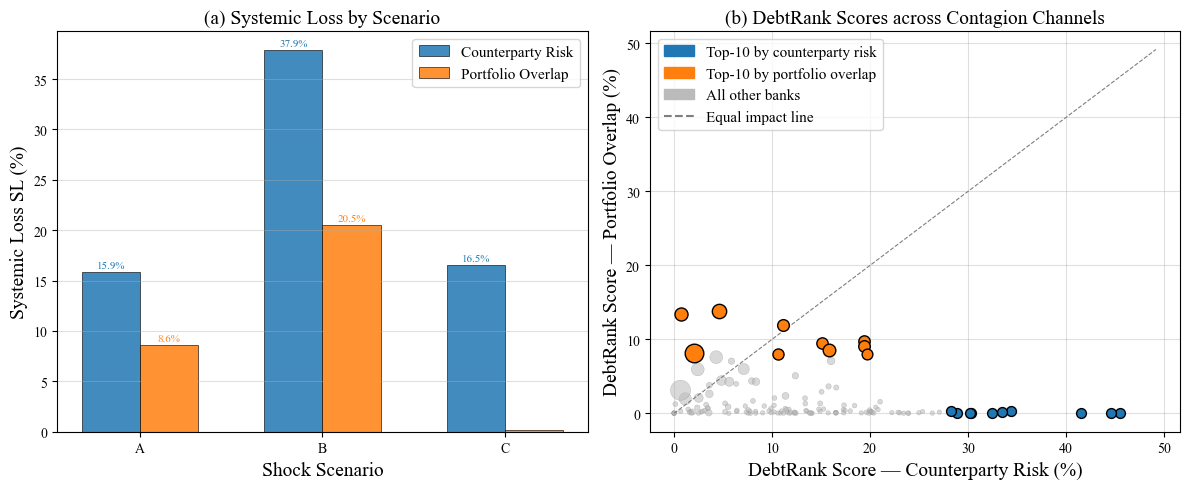

In [26]:
C1   = "#1f77b4"
C4   = "#ff7f0e"
GREY = "#7f7f7f"

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 5))

labels = ["A", "B", "C"]
x, w = np.arange(3), 0.32
b1 = ax.bar(x - w/2, [SL_A1*100, SL_B1*100, SL_C1*100], w, color=C1, alpha=0.85, edgecolor="black", lw=0.5, label="Counterparty Risk")
b2 = ax.bar(x + w/2, [SL_A2*100, SL_B2*100, SL_C2*100], w, color=C4, alpha=0.85, edgecolor="black", lw=0.5, label="Portfolio Overlap")

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4, f"{bar.get_height():.1f}%", ha="center", fontsize=8, color=C1)
for bar in b2:
    if bar.get_height() > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4, f"{bar.get_height():.1f}%", ha="center", fontsize=8, color=C4)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Systemic Loss SL (%)", fontsize=14)
ax.set_xlabel("Shock Scenario", fontsize=14)
ax.set_title("(a) Systemic Loss by Scenario", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)

eq_norm     = (equity - equity.min()) / (equity.max() - equity.min())
bubble_size = 10 + 200 * eq_norm

ax2.scatter(DR1_scores*100, DR2_scores*100,
            s=bubble_size, color="#bbbbbb",
            alpha=0.55, linewidths=0.3, edgecolors="#888888")

for idx in top10_DR1:
    ax2.scatter(DR1_scores[idx]*100, DR2_scores[idx]*100, color=C1, s=bubble_size[idx]+40, zorder=5, edgecolors="black")
for idx in top10_DR2:
    ax2.scatter(DR1_scores[idx]*100, DR2_scores[idx]*100, color=C4, s=bubble_size[idx]+40, zorder=5, edgecolors="black")

lim = max(DR1_scores.max(), DR2_scores.max()) * 100 * 1.08
ax2.plot([0, lim], [0, lim], color=GREY, lw=0.8, ls="--")

ax2.legend(handles=[
    mpatches.Patch(color=C1,    label="Top-10 by counterparty risk"),
    mpatches.Patch(color=C4,    label="Top-10 by portfolio overlap"),
    mpatches.Patch(color="#bbbbbb", label="All other banks"),
    plt.Line2D([0], [0], color=GREY, ls="--", label="Equal impact line")
], fontsize=11, loc="upper left")

ax2.set_xlabel("DebtRank Score — Counterparty Risk (%)", fontsize=14)
ax2.set_ylabel("DebtRank Score — Portfolio Overlap (%)", fontsize=14)
ax2.set_title("(b) DebtRank Scores across Contagion Channels", fontsize=14)
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()